In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
def generate_bernoulli(p, n):
    result = []
    for _ in range(n):
        result.append(1 if random.random() < p else 0)
    return result

## Histogramy dla $N = 10^7$, $p = 0.1, 0.5, 0.9$

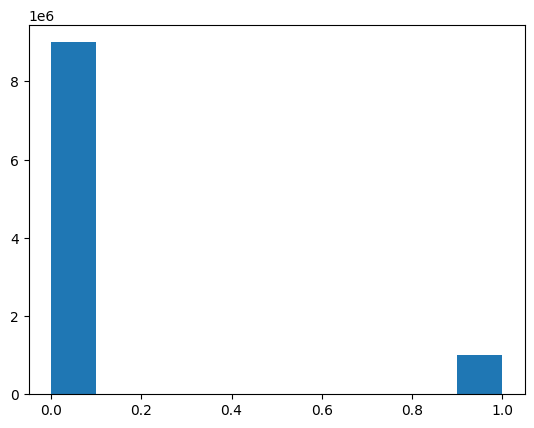

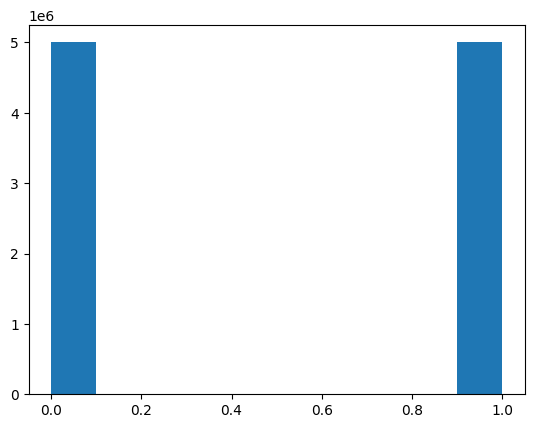

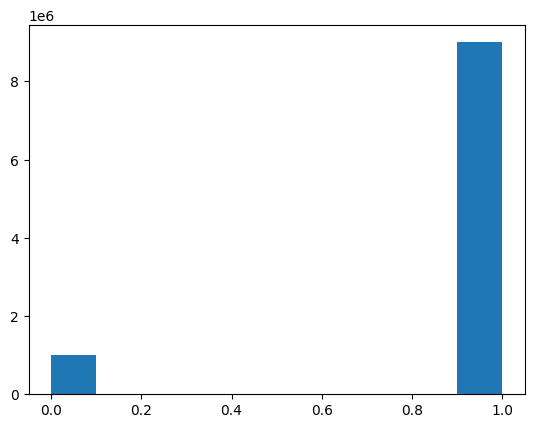

In [37]:
n = int(1e7)
p_arr = [0.1, 0.5, 0.9]

for p in p_arr:
    result = generate_bernoulli(p, n)
    
    plt.hist(result)
    plt.show()

In [3]:
p_values = [0.1, 0.5, 0.9]
n = int(1e7)
k_values = np.logspace(2, 7, num=6, dtype=int)

results = []


for p in p_values:
    bernoulli_samples = np.array(generate_bernoulli(p, n))

    arithm_means = []
    mean_variances = []
    theo_variances = []
    z_mean = []
    mean_err = []
    var_err = []

    for k in k_values:

        x_mean = np.mean(bernoulli_samples[:k])
        x_sqr_mean = np.mean(bernoulli_samples[:k] ** 2)
        x_var = (x_sqr_mean - x_mean ** 2) / k
        theo_var = p * (1 - p) / k

        arithm_means.append(x_mean)

        mean_variances.append(x_var)
        
        z_mean.append(p)

        theo_variances.append(theo_var)

        mean_err.append(np.abs(x_mean - p) / p)

        var_err.append(np.abs(x_var - theo_var) / theo_var)


    results.append((arithm_means, mean_variances, theo_variances, z_mean, mean_err, var_err))

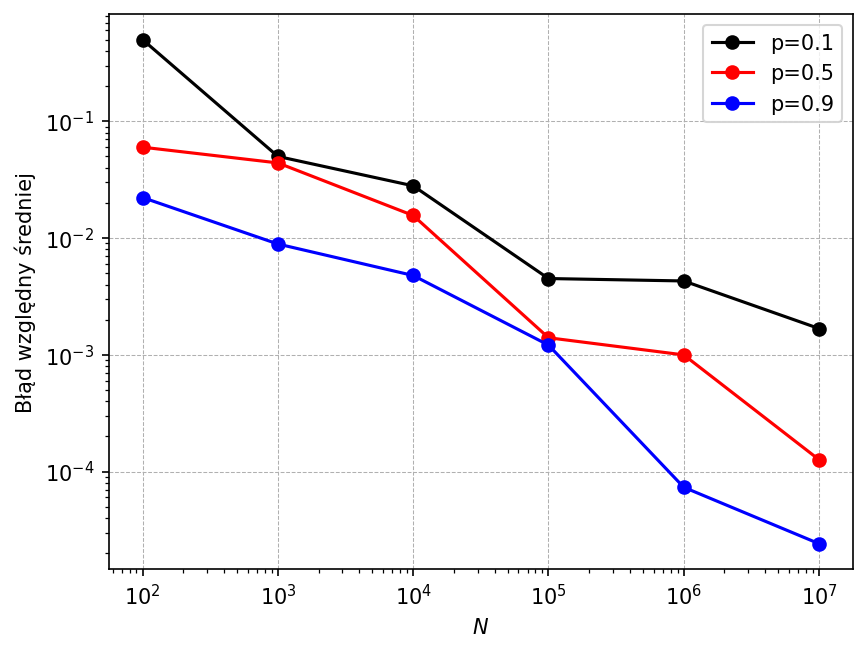

In [89]:
fig, ax = plt.subplots(dpi=150)

colors = ['black', 'red', 'blue']

for i, p in enumerate(p_values):
    x = k_values
    y = results[i][4]
    plt.plot(x, y, label=f'p={p}', marker='o', color=colors[i])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$N$')
ax.set_ylabel(r'Błąd względny średniej')
ax.legend()
ax.grid(lw=0.5, ls='--')

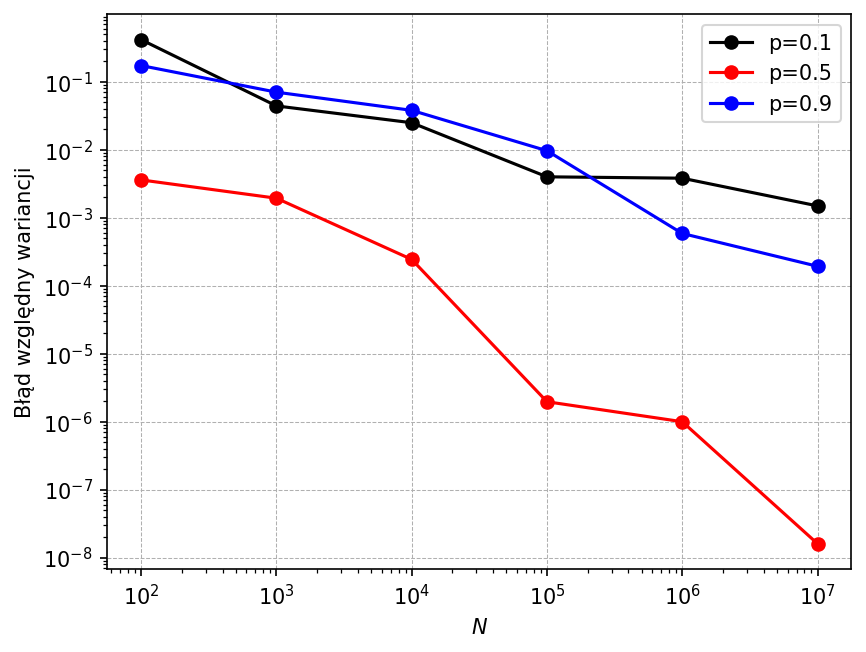

In [88]:
fig, ax = plt.subplots(dpi=150)

colors = ['black', 'red', 'blue']

for i, p in enumerate(p_values):
    x = k_values
    y = results[i][5]
    plt.plot(x, y, label=f'p={p}', marker='o', color=colors[i])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$N$')
ax.set_ylabel(r'Błąd względny wariancji')
ax.legend()
ax.grid(lw=0.5, ls='--')